In [1]:
import pandas as pd
import argparse


def count_column_values(csv_path: str, column: str, top_n: int = None, sort: bool = True):
    df = pd.read_csv(csv_path)

    if column not in df.columns:
        print(f"Column '{column}' not found.")
        print(f"Available columns: {list(df.columns)}")
        return

    counts = df[column].value_counts(dropna=False)

    if sort:
        counts = counts.sort_values(ascending=False)

    if top_n:
        counts = counts.head(top_n)


    return counts




counts = count_column_values('대학_교과목.csv', '교과목명', top_n=20, sort=False)
print(counts)



교과목명
인사행정론        13
재무행정론        13
행정학개론         9
공기업론          7
정부간관계론        6
한국행정론         6
정책분석평가론       6
도시행정론         6
행정학원론         5
행정조직론         5
정책학개론         5
조직행태론         5
조사방법론         5
독립심화학습1,2     4
정책평가론         4
정책분석및평가       4
지방재정론         4
환경정책론         4
복지행정론         4
지방행정론         4
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import os

# 폰트 캐시 삭제 후 재빌드 (나눔 폰트 인식을 위해)
cache_dir = matplotlib.get_cachedir()
for f in os.listdir(cache_dir):
    if "font" in f.lower():
        os.remove(os.path.join(cache_dir, f))

_font_path = "/home/jhahn/.local/lib/python3.10/site-packages/koreanize_matplotlib/fonts/NanumGothicLight.ttf"
fm.fontManager.addfont(_font_path)
_prop = fm.FontProperties(fname=_font_path)
matplotlib.rcParams["font.family"] = _prop.get_name()
matplotlib.rcParams["axes.unicode_minus"] = False

# 그래프 셀에서 공통으로 사용할 FontProperties
fp = fm.FontProperties(fname=_font_path, size=11)
fp_title = fm.FontProperties(fname=_font_path, size=14)
fp_tick = fm.FontProperties(fname=_font_path, size=9)
print(f"사용 폰트: {_prop.get_name()}")


사용 폰트: NanumGothic


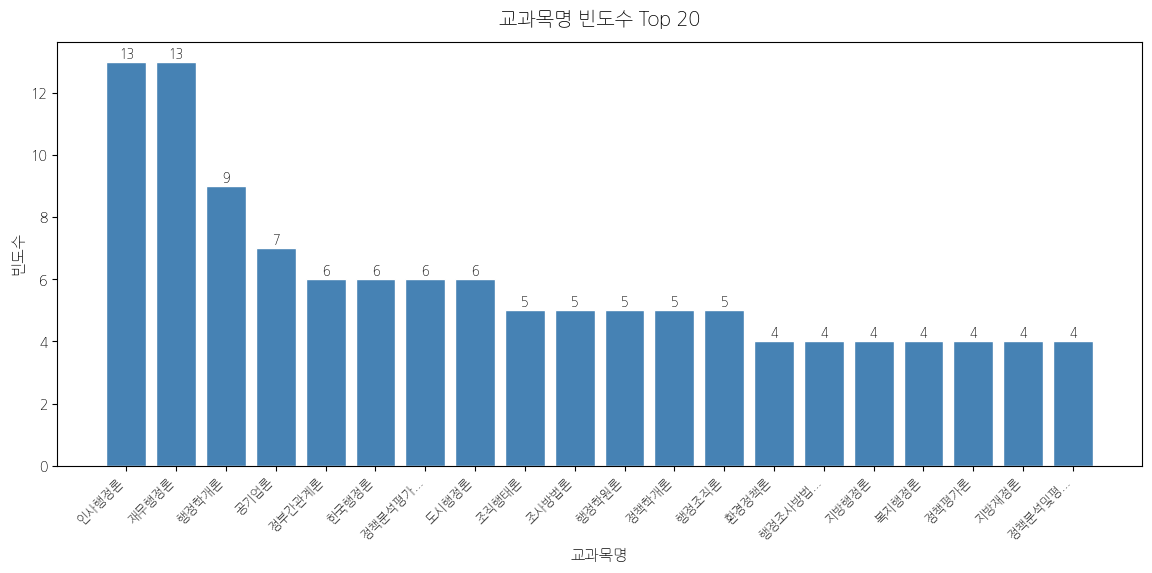

In [3]:
# ── 세로 막대 그래프: 교과목명 빈도수 Top 20 ──
top_n = 20
counts_subject = count_column_values("대학_교과목.csv", "교과목명", top_n=top_n, sort=True)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(range(len(counts_subject)), counts_subject.values, color="steelblue", edgecolor="white")

for bar, val in zip(bars, counts_subject.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(val), ha="center", va="bottom", fontproperties=fp_tick)

labels = [name[:6] + "..." if len(str(name)) > 6 else str(name) for name in counts_subject.index]
ax.set_xticks(range(len(counts_subject)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontproperties=fp_tick)

ax.set_title(f"교과목명 빈도수 Top {top_n}", fontproperties=fp_title, pad=12)
ax.set_xlabel("교과목명", fontproperties=fp)
ax.set_ylabel("빈도수", fontproperties=fp)
fig.subplots_adjust(bottom=0.35)
plt.savefig("keyword_bar.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── 수평 막대 그래프: 학교별 교과목 수 ──
counts_school = count_column_values("대학_교과목.csv", "학교", sort=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(counts_school) * 0.4)))
colors = plt.cm.tab20.colors[:len(counts_school)]
hbars = ax.barh(counts_school.index[::-1], counts_school.values[::-1],
                color=colors[::-1], edgecolor="white")

for bar, val in zip(hbars, counts_school.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontproperties=fp_tick)

ax.set_title("학교별 교과목 수", fontproperties=fp_title, pad=12)
ax.set_xlabel("교과목 수", fontproperties=fp)
for label in ax.get_yticklabels():
    label.set_fontproperties(fp)
plt.tight_layout()
plt.savefig("school_hbar.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── 워드 클라우드: 교과목명 키워드 ──
import re
from collections import Counter

try:
    from wordcloud import WordCloud
    import pandas as _pd

    df_wc = _pd.read_csv("대학_교과목.csv", encoding="utf-8-sig")

    def extract_keywords(text):
        if _pd.isna(text):
            return []
        text = re.sub(r"[a-zA-Z0-9]", " ", str(text))
        return re.findall(r"[가-힣]{2,}", text)

    all_kw = [kw for name in df_wc["교과목명"] for kw in extract_keywords(name)]
    kw_counter = Counter(all_kw)

    wc = WordCloud(
        font_path=_font_path,
        width=1000, height=600,
        background_color="white",
        max_words=120,
        colormap="tab20",
    ).generate_from_frequencies(dict(kw_counter))

    fig, ax = plt.subplots(figsize=(15, 8))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("교과목명 키워드 워드 클라우드", fontproperties=fp_title, pad=12)
    plt.tight_layout()
    plt.savefig("keyword_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("wordcloud 패키지가 없습니다. 설치: pip install wordcloud")
